In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [13]:
X = pd.read_csv("indian_engineering_student_placement.csv")
y = pd.read_csv("placement_targets.csv")

data = pd.merge(X, y, on="Student_ID")

In [14]:
data = data[data["placement_status"] == "Placed"]


features = [
    "cgpa",
    "internships_completed",
    "projects_completed",
    "coding_skill_rating",
    "communication_skill_rating",
    "aptitude_skill_rating",
    "attendance_percentage",
    "hackathons_participated",
    "certifications_count",
    "backlogs"
]

X = data[features]
y = data["salary_lpa"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

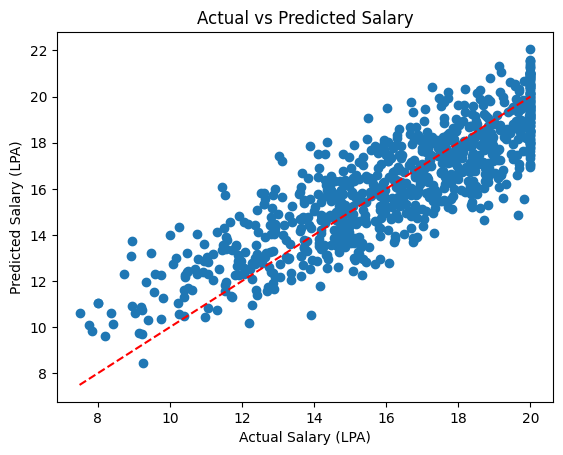

In [19]:
y_pred = model.predict(X_test)
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual Salary (LPA)")
plt.ylabel("Predicted Salary (LPA)")
plt.title("Actual vs Predicted Salary")
plt.show()

In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.7249867621256679
